In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:/ML/DataSet/placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
754,7.91,17.0,0
18,6.93,27.0,0
468,6.73,70.0,0
777,7.67,23.0,0
590,6.68,22.0,1


In [14]:
df.shape

(1000, 3)

In [3]:
df.isnull().mean()*100

cgpa                    0.0
placement_exam_marks    0.0
placed                  0.0
dtype: float64

C:\Users\Asus\AppData\Local\Temp\ipykernel_9856\3709739712.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_9856\3709739712.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

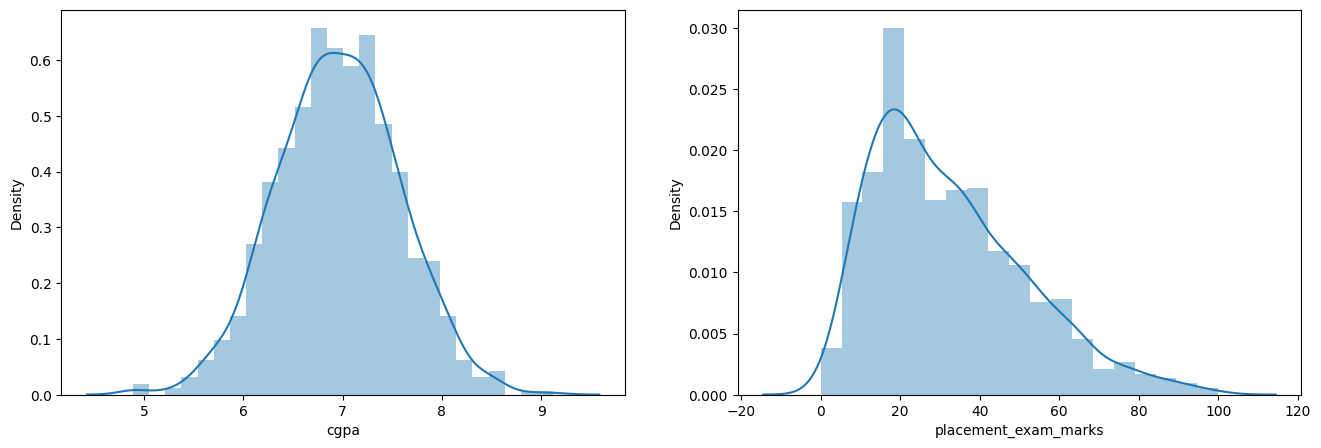

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['cgpa'])

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])

from this plot we can see that our cgpa is nicely normal while out marks is right skewed.

ence, we can say that we can only apply this z-score

In [6]:
print("Mean of CGPA =",df['cgpa'].mean())
print("Standard Deviation of CGPA =",df['cgpa'].std())  #This is the formula for the getting the stanard deviation of a numerical column and the square of this helps us to get variance
print("Minimum value of CGPA =",df['cgpa'].min())
print("Maximum value of CGPA =",df['cgpa'].max())

Mean of CGPA = 6.96124
Standard Deviation of CGPA = 0.6158978751323896
Minimum value of CGPA = 4.89
Maximum value of CGPA = 9.12


In [7]:
#finding the boundary values

print("Highest allowed :",df['cgpa'].mean()+3*df['cgpa'].std())
print("Lowest allowed :",df['cgpa'].mean()-3*df['cgpa'].std())

Highest allowed : 8.808933625397168
Lowest allowed : 5.113546374602832


In [9]:
#finding the outliers - learn this way

df[(df['cgpa']>8.809)|(df['cgpa']<5.114)]       #a|b -> means a or b

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## 1} Trimming

In [13]:
#Trimming 

new_df = df[(df['cgpa']<8.809)&(df['cgpa']>5.114)]      #we have made that the person following both criterias can only qualifies for new_df
new_df


,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [15]:
# Approach-2 -> calculating the Z-Score and using it to find the outliers and removing that

#calculating the Z-Score

df['cgpa_zscore'] = (df['cgpa']-df['cgpa'].mean())/(df['cgpa'].std())

In [16]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [17]:
df[df['cgpa_zscore']>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [18]:
df[df['cgpa_zscore']<-3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [19]:
df[(df['cgpa_zscore']>3)|(df['cgpa_zscore']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [21]:
#Trimming

new_df = df[(df['cgpa_zscore']<3)&(df['cgpa_zscore']>-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## 2} Capping

In [22]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [23]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

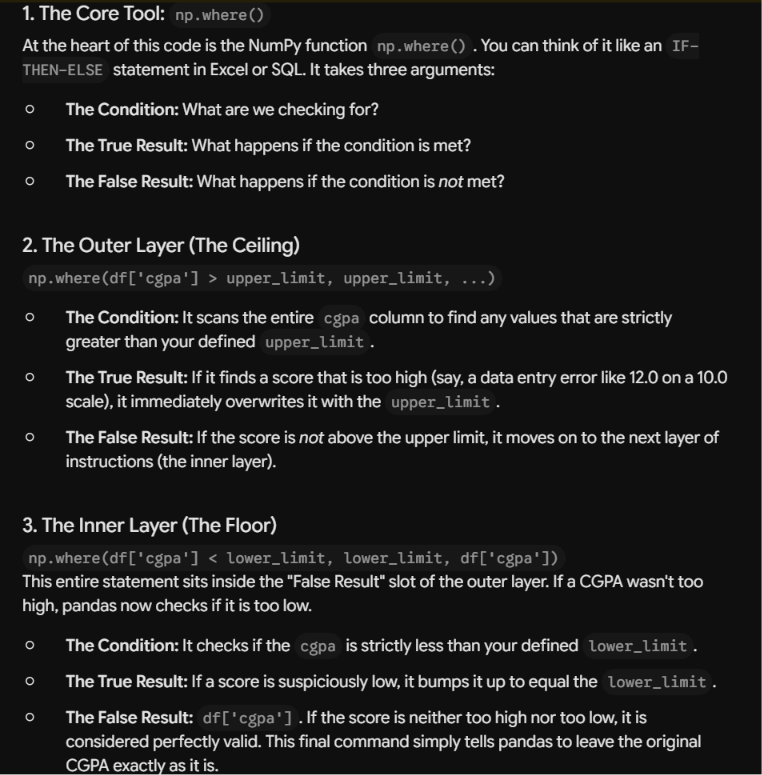
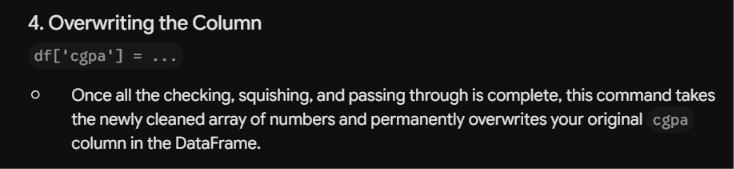

In [24]:
df.shape

(1000, 4)

In [25]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64